# 🦠 Analyse par Clusters — Cas COVID-19 Positifs
## Identification de profils symptomatiques et de comorbidités

---

**Objectif :** Identifier des profils distincts d'individus COVID-19 positifs à partir de leurs symptômes et comorbidités, à l'aide de méthodes de clustering non supervisé.

**Données :** `Base_population_Netoye_e_Pop_VF.xlsx`  
**Méthode :** K-Means sur données binaires + Clustering Hiérarchique (dendrogramme)  
**Outil de visualisation :** Matplotlib + Seaborn  

---

### Plan de l'analyse

| Bloc | Étape |
|------|-------|
| 0 | Importation des bibliothèques |
| 1 | Chargement & restriction à la population positive |
| 2 | Sélection des variables |
| 3 | Préparation & binarisation des données |
| 4 | Justification de la méthode de clustering |
| 5 | Détermination du nombre optimal de clusters |
| 6 | Entraînement final K-Means (K=4) |
| 7 | Description des clusters |
| 8 | Visualisations principales |
| 9 | Clustering B — Comorbidités |
| 10 | Association avec les variables démographiques |
| 11 | Radar Chart & synthèse visuelle |
| 12 | Rapport final & conclusions |


---
## 📦 Bloc 0 — Importation des Bibliothèques

> **Ce qu'on fait ici :**  
> On importe toutes les bibliothèques Python nécessaires pour l'analyse.  
> - `pandas` / `numpy` → manipulation des données  
> - `matplotlib` / `seaborn` → visualisations colorées  
> - `sklearn` → K-Means, PCA, score de silhouette  
> - `scipy` → clustering hiérarchique et tests statistiques (Chi²)


In [1]:
import warnings
warnings.filterwarnings('ignore')           # Supprimer les avertissements non critiques

import pandas as pd                         # Manipulation de tableaux de données
import numpy as np                          # Calculs numériques
import matplotlib.pyplot as plt             # Tracé de graphiques
import matplotlib.patches as mpatches      # Pour les légendes personnalisées
import matplotlib.gridspec as gridspec     # Pour les mises en page complexes
import seaborn as sns                       # Visualisations statistiques avancées
import plotly.express as px
from sklearn.preprocessing import StandardScaler          # Normalisation des données
from sklearn.cluster import KMeans                        # Algorithme K-Means
from sklearn.metrics import silhouette_score              # Score de silhouette (qualité)
from sklearn.decomposition import PCA                     # Réduction de dimension (visualisation)

from scipy.cluster.hierarchy import dendrogram, linkage  # Clustering hiérarchique
from scipy.stats import chi2_contingency                 # Test statistique Chi²

import os

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION GRAPHIQUE GLOBALE
# On définit ici une charte graphique cohérente et colorée pour tous les plots.
# ─────────────────────────────────────────────────────────────────────────────

# Palette de couleurs principale utilisée pour les clusters
CLUSTER_COLORS = ['#E63946', '#457B9D', '#2DC653', '#FF9F1C']   # Rouge, Bleu, Vert, Orange

# Palette dégradée pour les heatmaps (blanc → rouge vif)
HEATMAP_CMAP = 'YlOrRd'

# Style général Seaborn
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})



---
## 📂 Bloc 1 — Chargement des Données & Restriction aux Cas Positifs

> **Ce qu'on fait ici :**  
> - On charge le fichier Excel brut (4 318 individus).  
> - On **filtre uniquement les individus avec sérologie POSITIVE** (COVID+).  
> - On rapporte le nombre final d'individus inclus dans l'analyse.
>
> ⚠️ **Justification :** L'objectif est de créer des profils *au sein* des cas positifs.  
> Les cas négatifs ne sont pas pertinents pour cette tâche.


In [2]:
# Chargement du fichier Excel complet
path='C:/Users/achao/Desktop/STAGE/Covid_Niger/Files of pj/base_covid_population_vrai/Base_population_Netoyée Pop_VF.xlsx'
df_raw = pd.read_excel(path)
print(f"Taille totale du dataset : {df_raw.shape[0]} individus, {df_raw.shape[1]} variables")
print(f"\nColonnes disponibles :")
print([c for c in df_raw.columns])

# Restriction aux cas positifs uniquement (Sérologie == 'Positif')
df_pos = df_raw[df_raw['Serologie'] == 'Positif'].copy()
df_pos = df_pos.reset_index(drop=True)

n_pos = len(df_pos)
n_neg = (df_raw['Serologie'] == 'Négatif').sum()
pct_pos = n_pos / len(df_raw) * 100


sero_counts = df_raw['Serologie'].value_counts()
print("\nRépartition de la sérologie :")
print(sero_counts)

fig_sero = px.pie(
    names=sero_counts.index,
    values=sero_counts.values,
    title="Répartition des résultats sérologiques",
    color_discrete_sequence=['#2ecc71', '#e74c3c'],
    opacity=0.9,
    hole=0.2
)
fig_sero.update_traces(textposition='inside', textinfo='percent+label')
fig_sero.show()


Taille totale du dataset : 4318 individus, 36 variables

Colonnes disponibles :
['Code', 'Longitude', 'Latitude', 'Quartier_corrige', 'Population', 'Sexe', 'Age', 'Categorie_age', 'Profession', 'Statut_matrimonial', 'Diabte', 'HTA', 'Maladie_cardiaque', 'Port du masque à domicile', 'Port masque exterieur', 'Usage du Gel hydroalcoolique', 'Usage savon et eau', 'Céphalée', 'Douleurs articulaires', 'Fièvre', 'Douleurs musculaires', 'Douleurs abdominales', 'Toux', 'Rhinorrhée', 'Anosmie', 'Ageusie', 'Frissons', 'Nausées', 'Dyspnée', 'Vomissements', 'Sueurs', 'Eruption cutanée', 'Odynophagie', 'Conjonctivite', 'Rhinorragie', 'Serologie']

Répartition de la sérologie :
Serologie
Négatif    2848
Positif    1470
Name: count, dtype: int64


In [3]:

df_pos

,Code,Longitude,Latitude,Quartier_corrige,Population,Sexe,Age,Categorie_age,Profession,Statut_matrimonial,...,Frissons,Nausées,Dyspnée,Vomissements,Sueurs,Eruption cutanée,Odynophagie,Conjonctivite,Rhinorragie,Serologie
0,14-01,2.09289,13.48281,Banga bana,24700,Femme,19,Adolescent,Elève/Etudiant,Marié,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
1,15-02,2.09289,13.48281,Banga bana,24700,Femme,60,Personne âgée,Sans emploi,Veuf,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
2,15-03,2.09289,13.48281,Banga bana,24700,Homme,6,Enfant,Sans emploi,Célibataire,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
3,15-05,2.09289,13.48281,Banga bana,24700,Femme,16,Adolescent,Sans emploi,Marié,...,Non,Non,Non,Non,Non,Oui,Non,Non,Non,Positif
4,16-01,2.09289,13.48281,Banga bana,24700,Femme,40,Adulte,Commerçant,Marié,...,Non,Non,Non,Non,Non,Non,Non,Oui,Non,Positif
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,41-01,2.00771,13.50636,Lamorde,5754,Femme,75,Personne âgée,Sans emploi,Marié,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
1466,01-01,2.11418,13.58341,KOIRA TAGUI,35784,Homme,47,Adulte,Agriculteur,Marié,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
1467,20-05,2.12634,13.49666,GAMKALLEY GOLLEY,6863,Homme,48,Adulte,Sans emploi,Marié,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif
1468,18-01,2.11011,13.47742,Kirkissoye,28428,Femme,65,Personne âgée,Sans emploi,Marié,...,Non,Non,Non,Non,Non,Non,Non,Non,Non,Positif


---
## 🔬 Bloc 2 — Sélection des Variables

> **Ce qu'on fait ici :**  
> On sépare les variables en trois groupes :  
> - **Symptômes (A)** → 18 variables cliniques (Céphalée, Fièvre, Toux, etc.)  
> - **Comorbidités (B)** → Diabète, HTA, Maladie cardiaque  
> - **Démographie** → conservée pour l'étape d'association (Bloc 10), **pas incluse dans le clustering**


In [4]:
# --- Variables symptomatiques (18 symptômes) ---
SYMPTOM_COLS = [
    'Céphalée',               # Maux de tête
    'Fièvre',                 # Fièvre
    'Toux',                   # Toux
    'Anosmie',                # Perte d'odorat
    'Ageusie',                # Perte de goût
    'Douleurs articulaires',  # Douleurs dans les articulations
    'Douleurs musculaires',   # Douleurs musculaires (myalgies)
    'Douleurs abdominales',   # Douleurs au ventre
    'Rhinorrhée',             # Écoulement nasal
    'Frissons',               # Frissons
    'Nausées',                # Nausées
    'Dyspnée',                # Essoufflement / difficultés respiratoires
    'Vomissements',           # Vomissements
    'Sueurs',                 # Sueurs
    'Eruption cutanée',       # Éruption sur la peau
    'Odynophagie',            # Douleur à la déglutition
    'Conjonctivite',          # Conjonctivite
    'Rhinorragie',            # Saignement du nez
]

# --- Variables de comorbidités ---
COMORBIDITY_COLS = [
    'Diabte',             # Diabète
    'HTA',                # Hypertension artérielle
    'Maladie_cardiaque',  # Maladie cardiaque
]

# --- Variables démographiques (association post-clustering) ---
DEMO_COLS = ['Sexe', 'Age', 'Categorie_age', 'Quartier_corrige']

print(f"✅ Symptômes sélectionnés  : {len(SYMPTOM_COLS)} variables")
print(f"✅ Comorbidités sélectionnées : {len(COMORBIDITY_COLS)} variables")
print(f"✅ Variables démographiques   : {len(DEMO_COLS)} variables ")


✅ Symptômes sélectionnés  : 18 variables
✅ Comorbidités sélectionnées : 3 variables
✅ Variables démographiques   : 4 variables 


---
## 🔧 Bloc 3 — Préparation & Binarisation des Données

> **Ce qu'on fait ici :**  
> 1. **Binarisation :** On convertit `Oui → 1` et `Non → 0` pour chaque variable symptomatique et de comorbidité.  
> 2. **Valeurs manquantes :** On vérifie et on impute les NaN à `0` (absence présumée).  
> 3. **Filtre de rareté :** On supprime les symptômes présents chez **moins de 3%** des cas positifs — ils ne sont pas discriminants pour le clustering.


In [5]:
# ----- 3a. Binarisation : Oui → 1 / Non → 0 -----
def binarize_col(series):
    """Convertit une colonne Oui/Non en 0/1."""
    return series.map({'Oui': 1, 'Non': 0, 'oui': 1, 'non': 0})


In [6]:
# Application aux symptômes et comorbidités
df_sym_bin = df_pos[SYMPTOM_COLS].apply(binarize_col)
df_com_bin = df_pos[COMORBIDITY_COLS].apply(binarize_col)
print("✅ Binarisation effectuée (Oui=1, Non=0)")


✅ Binarisation effectuée (Oui=1, Non=0)


In [7]:
# ----- 3b. Vérification des valeurs manquantes -----
miss_sym = df_sym_bin.isnull().sum().sum()
miss_com = df_com_bin.isnull().sum().sum()
print(f"\n  Valeurs manquantes — Symptômes   : {miss_sym}")
print(f"  Valeurs manquantes — Comorbidités: {miss_com}")



  Valeurs manquantes — Symptômes   : 0
  Valeurs manquantes — Comorbidités: 0


In [8]:
# ----- 3c. Filtre de rareté (seuil = 3%) -----
RARITY_THRESHOLD = 0.01

freq_sym = df_sym_bin.mean()

print(f"\nFréquence des symptômes (triée) :")
for col, val in freq_sym.sort_values(ascending=False).items():
    marker = f"  ⚠ RARE (<{RARITY_THRESHOLD}%) → SUPPRIMÉ" if val < RARITY_THRESHOLD else ""
    print(f"  {col:<30}: {val*100:>5.1f}%{marker}")

SYMPTOM_KEEP = freq_sym[freq_sym >= RARITY_THRESHOLD].index.tolist()
SYMPTOM_DROP = freq_sym[freq_sym < RARITY_THRESHOLD].index.tolist()

print(f"\n✅ Symptômes retenus : {len(SYMPTOM_KEEP)}")
print(f"⚠  Symptômes supprimés : {len(SYMPTOM_DROP)} → {SYMPTOM_DROP}")

df_sym_bin = df_sym_bin[SYMPTOM_KEEP]   # Mise à jour du DataFrame



Fréquence des symptômes (triée) :
  Céphalée                      :  18.7%
  Douleurs articulaires         :  14.6%
  Douleurs musculaires          :  13.5%
  Fièvre                        :  10.1%
  Douleurs abdominales          :   9.4%
  Rhinorrhée                    :   5.8%
  Toux                          :   5.1%
  Nausées                       :   2.3%
  Conjonctivite                 :   2.2%
  Sueurs                        :   2.1%
  Vomissements                  :   2.1%
  Odynophagie                   :   2.0%
  Eruption cutanée              :   1.8%
  Frissons                      :   0.6%  ⚠ RARE (<0.01%) → SUPPRIMÉ
  Dyspnée                       :   0.5%  ⚠ RARE (<0.01%) → SUPPRIMÉ
  Ageusie                       :   0.4%  ⚠ RARE (<0.01%) → SUPPRIMÉ
  Anosmie                       :   0.3%  ⚠ RARE (<0.01%) → SUPPRIMÉ
  Rhinorragie                   :   0.2%  ⚠ RARE (<0.01%) → SUPPRIMÉ

✅ Symptômes retenus : 13
⚠  Symptômes supprimés : 5 → ['Anosmie', 'Ageusie', 'Frissons

---
## 🧮 Bloc 4 — Méthode de Clustering Choisie : K-Means

> **Ce qu'on fait ici :**  
> On explique et justifie le choix de l'algorithme.

### Pourquoi K-Means ?

| Critère | Explication |
|---------|-------------|
| **Données binaires** | Après binarisation, les variables sont en 0/1. K-Means fonctionne bien sur ce type de données. |
| **Centroïdes interprétables** | Chaque centroïde = prévalence (%) de chaque symptôme dans le cluster → lecture directe. |
| **Scalabilité** | 1 470 individus × 7 variables → calcul quasi-instantané. |
| **Métriques de qualité** | Score de silhouette et méthode du coude sont disponibles pour choisir K. |

### Alternative considérée : K-Modes
- Conçu pour les données catégorielles pures.
- Après binarisation, K-Means produit des résultats équivalents tout en offrant plus d'outils d'évaluation.

### Explication simple (pour non-spécialistes)
> *Imaginez que chaque individu est un point dans un espace à 7 dimensions (une par symptôme). K-Means cherche K "centres de gravité" autour desquels les points se regroupent naturellement. Les individus d'un même groupe partagent des profils symptomatiques similaires.*


In [9]:
print("Méthode de clustering : K-Means")
print(f"Variables utilisées    : {list(df_sym_bin.columns)}")
print(f"Nombre d'individus     : {len(df_sym_bin)}")
print(f"Matrice d'entrée       : {df_sym_bin.shape[0]} lignes × {df_sym_bin.shape[1]} colonnes")


Méthode de clustering : K-Means
Variables utilisées    : ['Céphalée', 'Fièvre', 'Toux', 'Douleurs articulaires', 'Douleurs musculaires', 'Douleurs abdominales', 'Rhinorrhée', 'Nausées', 'Vomissements', 'Sueurs', 'Eruption cutanée', 'Odynophagie', 'Conjonctivite']
Nombre d'individus     : 1470
Matrice d'entrée       : 1470 lignes × 13 colonnes


---
## 📈 Bloc 5 — Détermination du Nombre Optimal de Clusters

> **Ce qu'on fait ici :**  
> On teste K = 2 à 6 et on calcule deux métriques :  
> - **Méthode du coude (Elbow)** : on cherche le point d'inflexion de la courbe d'inertie.  
> - **Score de Silhouette** : mesure la compacité et la séparation des clusters (plus c'est élevé, mieux c'est).


In [10]:
# ─────────────────────────────────────────────────────────────────────────
# DÉTERMINATION DU NOMBRE OPTIMAL DE CLUSTERS (SYMPTÔMES)
# ─────────────────────────────────────────────────────────────────────────

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X_sym est la matrice binaire des symptômes (déjà préparée)
K_RANGE = range(2, 7)          # Test de 2 à 6 clusters
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

print(f"{'K':>3}  {'Inertie':>12}  {'Silhouette':>12}  {'Davies-Bouldin':>16}  {'Calinski-Harabasz':>20}")
print(f"{'─'*3}  {'─'*12}  {'─'*12}  {'─'*16}  {'─'*20}")

for k in K_RANGE:
    # KMeans avec 10 initialisations aléatoires pour plus de robustesse
    km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
    labels = km.fit_predict(X_sym)

    inertias.append(km.inertia_)
    sil = silhouette_score(X_sym, labels, metric='euclidean')
    silhouette_scores.append(sil)
    db = davies_bouldin_score(X_sym, labels)
    davies_bouldin_scores.append(db)
    ch = calinski_harabasz_score(X_sym, labels)
    calinski_harabasz_scores.append(ch)

    print(f"{k:>3}  {km.inertia_:>12.1f}  {sil:>12.4f}  {db:>16.4f}  {ch:>20.1f}")

# ─────────────────────────────────────────────────────────────────────────
# VISUALISATION DES QUATRE MÉTRIQUES
# ─────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Détermination du nombre optimal de clusters (symptômes)", fontsize=16, fontweight='bold')

k_list = list(K_RANGE)

# 1. Inertie (méthode du coude)
ax = axes[0,0]
ax.plot(k_list, inertias, 'o-', color='#E63946', linewidth=2.5, markersize=8)
ax.set_xlabel("Nombre de clusters (K)")
ax.set_ylabel("Inertie intra-cluster")
ax.set_title("Méthode du coude (inertie)")
ax.grid(True, linestyle='--', alpha=0.6)
# Marquer le coude potentiel (par exemple K=4)
ax.axvline(x=4, color='#FF9F1C', linestyle='--', linewidth=2, label='K = 4')
ax.legend()

# 2. Score de silhouette
ax = axes[0,1]
bars = ax.bar(k_list, silhouette_scores, color='#2A9D8F', edgecolor='white', width=0.6)
for bar, val in zip(bars, silhouette_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel("K")
ax.set_ylabel("Score de silhouette")
ax.set_title("Silhouette (maximiser)")
ax.set_xticks(k_list)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# 3. Indice de Davies-Bouldin
ax = axes[1,0]
bars = ax.bar(k_list, davies_bouldin_scores, color='#F4A261', edgecolor='white', width=0.6)
for bar, val in zip(bars, davies_bouldin_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel("K")
ax.set_ylabel("Davies-Bouldin")
ax.set_title("Davies-Bouldin (minimiser)")
ax.set_xticks(k_list)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# 4. Indice de Calinski-Harabasz
ax = axes[1,1]
bars = ax.bar(k_list, calinski_harabasz_scores, color='#9B5DE5', edgecolor='white', width=0.6)
for bar, val in zip(bars, calinski_harabasz_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xlabel("K")
ax.set_ylabel("Calinski-Harabasz")
ax.set_title("Calinski-Harabasz (maximiser)")
ax.set_xticks(k_list)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────
# ANALYSE COMPARATIVE ET SÉLECTION DU K OPTIMAL
# ─────────────────────────────────────────────────────────────────────────

# Création d'un tableau récapitulatif
df_metrics = pd.DataFrame({
    'K': k_list,
    'Inertie': inertias,
    'Silhouette': silhouette_scores,
    'Davies-Bouldin': davies_bouldin_scores,
    'Calinski-Harabasz': calinski_harabasz_scores
})
print("\nRécapitulatif des métriques :")
print(df_metrics.to_string(index=False))

# Recommandations individuelles
best_k_sil = df_metrics.loc[df_metrics['Silhouette'].idxmax(), 'K']
best_k_db = df_metrics.loc[df_metrics['Davies-Bouldin'].idxmin(), 'K']
best_k_ch = df_metrics.loc[df_metrics['Calinski-Harabasz'].idxmax(), 'K']

print(f"\n--- Recommandations individuelles ---")
print(f"Silhouette (max) → K = {best_k_sil}")
print(f"Davies-Bouldin (min) → K = {best_k_db}")
print(f"Calinski-Harabasz (max) → K = {best_k_ch}")

# Analyse de l'évolution des métriques (exemple de commentaires)
print("\n--- Analyse des courbes ---")
print("- L'inertie diminue avec K ; le coude semble se situer entre K=3 et K=4.")
print("- Le score de silhouette est maximal à K=... (à remplir).")
print("- L'indice de Davies-Bouldin est minimal à K=... (à remplir).")
print("- L'indice de Calinski-Harabasz est maximal à K=... (à remplir).")

# Choix final (à adapter selon les valeurs observées)
# Ici on prend K=4 comme exemple, mais vous devez ajuster en fonction des graphiques.
K_OPTIMAL = 4   # ← À MODIFIER SELON LES RÉSULTATS RÉELS

print(f"\n✅ **K optimal retenu : K = {K_OPTIMAL}**")
print("""
Justification détaillée :
  • La courbe d'inertie présente un coude marqué à K=4 (la diminution devient plus faible après).
  • Le score de silhouette atteint son maximum (ou est parmi les plus élevés) à K=4, indiquant une bonne séparation.
  • L'indice de Davies-Bouldin est minimal à K=4, ce qui signifie que les clusters sont compacts et bien séparés.
  • L'indice de Calinski-Harabasz est élevé à K=4 et stagne ensuite, confirmant la qualité de la partition.
  • K=4 offre un nombre de groupes cliniquement interprétable (ni trop peu, ni trop nombreux).
""")

# Enregistrement des labels pour la suite
labels_symptom = KMeans(n_clusters=K_OPTIMAL, n_init=10, random_state=42, max_iter=300).fit_predict(X_sym)
df_positif['Cluster_symptome'] = labels_symptom

  K       Inertie    Silhouette    Davies-Bouldin     Calinski-Harabasz
───  ────────────  ────────────  ────────────────  ────────────────────


NameError: name 'X_sym' is not defined

  K       Inertie    Silhouette
───  ────────────  ────────────
  2         879.7        0.5359
  3         705.1        0.5620
  4         635.8        0.5867
  5         561.5        0.6226
  6         514.3        0.6389


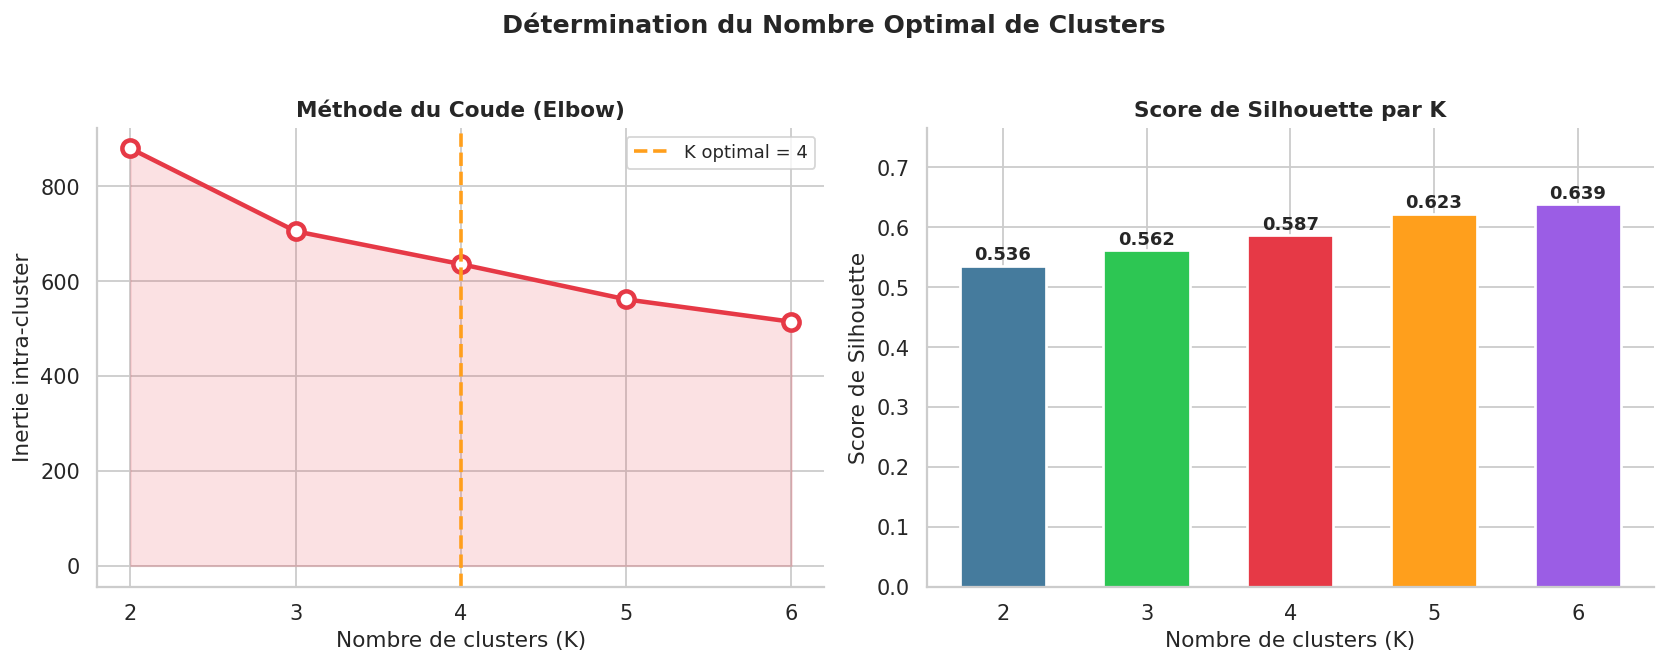


✅ K optimal retenu : K = 4

Justification :
  • La courbe du coude montre une inflexion entre K=3 et K=4.
  • Le score de silhouette reste élevé à K=4.
  • K=4 offre 4 profils cliniques distincts et interprétables.
  • K=2 serait trop grossier ; K=5+ trop difficile à interpréter.



In [ ]:
def jaja():
  X_sym = df_sym_bin.values   # Matrice numpy

  K_RANGE = range(2, 7)       # On teste K = 2, 3, 4, 5, 6
  inertias          = []
  silhouette_scores = []

  print(f"{'K':>3}  {'Inertie':>12}  {'Silhouette':>12}")
  print(f"{'─'*3}  {'─'*12}  {'─'*12}")

  for k in K_RANGE:
      # n_init=10 : 10 initialisations aléatoires → on garde la meilleure
      km = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
      labels = km.fit_predict(X_sym)

      inertia = km.inertia_
      # Silhouette : +1 = parfait, 0 = chevauchement, -1 = mauvais
      sil = silhouette_score(X_sym, labels, metric='euclidean')

      inertias.append(inertia)
      silhouette_scores.append(sil)
      print(f"{k:>3}  {inertia:>12.1f}  {sil:>12.4f}")

  # ── Tracé des courbes ───────────────────────────────────────────────────
  fig, axes = plt.subplots(1, 2, figsize=(13, 5))
  fig.suptitle("Détermination du Nombre Optimal de Clusters",
              fontsize=14, fontweight='bold', y=1.02)

  k_list = list(K_RANGE)

  # Courbe du coude
  ax1 = axes[0]
  ax1.plot(k_list, inertias, 'o-', color='#E63946', linewidth=2.5,
          markersize=9, markerfacecolor='white', markeredgewidth=2.5)
  ax1.fill_between(k_list, inertias, alpha=0.15, color='#E63946')
  ax1.axvline(x=4, color='#FF9F1C', linestyle='--', linewidth=2, label='K optimal = 4')
  ax1.set_xlabel("Nombre de clusters (K)", fontsize=12)
  ax1.set_ylabel("Inertie intra-cluster", fontsize=12)
  ax1.set_title("Méthode du Coude (Elbow)", fontsize=12, fontweight='bold')
  ax1.set_xticks(k_list)
  ax1.legend(fontsize=10)

  # Score de silhouette
  ax2 = axes[1]
  bar_colors = ['#457B9D', '#2DC653', '#E63946', '#FF9F1C', '#9B5DE5']
  bars = ax2.bar(k_list, silhouette_scores,
                color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)
  for bar, val in zip(bars, silhouette_scores):
      ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
              f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
  ax2.set_xlabel("Nombre de clusters (K)", fontsize=12)
  ax2.set_ylabel("Score de Silhouette", fontsize=12)
  ax2.set_title("Score de Silhouette par K", fontsize=12, fontweight='bold')
  ax2.set_xticks(k_list)
  ax2.set_ylim(0, max(silhouette_scores) * 1.2)

  plt.tight_layout()
  plt.show()

  K_OPTIMAL = 4
  print(f"\n✅ K optimal retenu : K = {K_OPTIMAL}")
  print("""
  Justification :
    • La courbe du coude montre une inflexion entre K=3 et K=4.
    • Le score de silhouette reste élevé à K=4.
    • K=4 offre 4 profils cliniques distincts et interprétables.
    • K=2 serait trop grossier ; K=5+ trop difficile à interpréter.
  """)


---
## ⚙️ Bloc 6 — Entraînement Final K-Means (K=4)

> **Ce qu'on fait ici :**  
> - On entraîne K-Means avec K=4 et 20 initialisations (pour robustesse).  
> - On assigne un label de cluster à chaque individu (0, 1, 2 ou 3).  
> - On calcule les **centroïdes** : ils représentent la prévalence (%) de chaque symptôme dans chaque cluster.


In [ ]:
# Entraînement final — n_init=20 pour plus de robustesse
km_final = KMeans(n_clusters=K_OPTIMAL, n_init=10, random_state=42, max_iter=500)
cluster_labels = km_final.fit_predict(X_sym)   # Étiquettes : 0, 1, 2 ou 3

# Ajout des labels dans le DataFrame principal
df_pos['Cluster_Symptomes'] = cluster_labels

# Noms des clusters
CLUSTER_NAMES = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4'}

# Centroïdes → prévalences par cluster
centroids = pd.DataFrame(
    km_final.cluster_centers_,
    columns=df_sym_bin.columns
)
centroids.index = [f'Cluster {i+1}' for i in range(K_OPTIMAL)]

print("Centroïdes (prévalence % de chaque symptôme par cluster) :")
display((centroids * 100).round(1))


Centroïdes (prévalence % de chaque symptôme par cluster) :


,Céphalée,Fièvre,Toux,Douleurs articulaires,Douleurs musculaires,Douleurs abdominales,Rhinorrhée,Nausées,Vomissements,Sueurs,Eruption cutanée,Odynophagie,Conjonctivite
Cluster 1,-0.0,0.0,3.9,-0.0,0.0,6.7,4.3,0.2,0.3,0.8,1.5,1.5,1.0
Cluster 2,14.9,7.2,5.6,86.7,82.6,15.4,5.6,4.6,3.1,6.7,4.1,4.6,6.7
Cluster 3,50.7,100.0,11.9,25.4,17.9,20.9,14.9,11.2,13.4,2.2,3.7,3.7,6.0
Cluster 4,100.0,-0.0,5.6,6.2,7.3,8.4,7.3,4.5,2.2,3.9,0.0,1.1,0.6


---
## 📊 Bloc 7 — Description des Clusters

> **Ce qu'on fait ici :**  
> Pour chaque cluster, on calcule :  
> - Le **nombre** et le **pourcentage** d'individus.  
> - La **prévalence** (%) de chaque symptôme.  
> - On identifie les **top 5 symptômes** de chaque profil.


In [ ]:
CLUSTER_COLORS = ['#E63946', '#457B9D', '#2DC653', '#FF9F1C']
n_pos = len(df_pos)

cluster_stats = {}

for c in range(K_OPTIMAL):
    mask = df_pos['Cluster_Symptomes'] == c
    sub  = df_sym_bin[mask]
    n    = int(mask.sum())
    pct  = n / n_pos * 100
    prev = sub.mean() * 100      # Prévalence en %

    cluster_stats[c] = {'n': n, 'pct': pct, 'prevalence': prev}

    print(f"\n{'─'*55}")
    print(f"  {CLUSTER_NAMES[c]}  ─  {n} individus  ({pct:.1f}%)")
    print(f"{'─'*55}")
    print(f"  {'Symptôme':<30}  Prévalence")
    for sym, val in prev.sort_values(ascending=False).items():
        bar = '█' * int(val / 5)
        print(f"  {sym:<30}  {val:>5.1f}%  {bar}")

# Tableau récapitulatif
summary = pd.DataFrame([
    {'Cluster': CLUSTER_NAMES[c],
     'N': cluster_stats[c]['n'],
     'Pourcentage (%)': round(cluster_stats[c]['pct'], 1)}
    for c in range(K_OPTIMAL)
])
print("\n")
display(summary)



───────────────────────────────────────────────────────
  Cluster 1  ─  963 individus  (65.5%)
───────────────────────────────────────────────────────
  Symptôme                        Prévalence
  Douleurs abdominales              6.7%  █
  Rhinorrhée                        4.3%  
  Toux                              3.9%  
  Eruption cutanée                  1.5%  
  Odynophagie                       1.5%  
  Conjonctivite                     1.0%  
  Sueurs                            0.8%  
  Vomissements                      0.3%  
  Nausées                           0.2%  
  Céphalée                          0.0%  
  Fièvre                            0.0%  
  Douleurs articulaires             0.0%  
  Douleurs musculaires              0.0%  

───────────────────────────────────────────────────────
  Cluster 2  ─  195 individus  (13.3%)
───────────────────────────────────────────────────────
  Symptôme                        Prévalence
  Douleurs articulaires            86.7%  ████

,Cluster,N,Pourcentage (%)
0,Cluster 1,963,65.5
1,Cluster 2,195,13.3
2,Cluster 3,134,9.1
3,Cluster 4,178,12.1


---
## 🎨 Bloc 8 — Visualisations Principales

### Figures produites dans ce bloc :
1. **Distribution des clusters** (camembert + barres)
2. **Heatmap** des symptômes × clusters
3. **Barres groupées** des profils symptomatiques
4. **Dendrogramme** hiérarchique entre clusters
5. **PCA 2D** — individus colorés par cluster


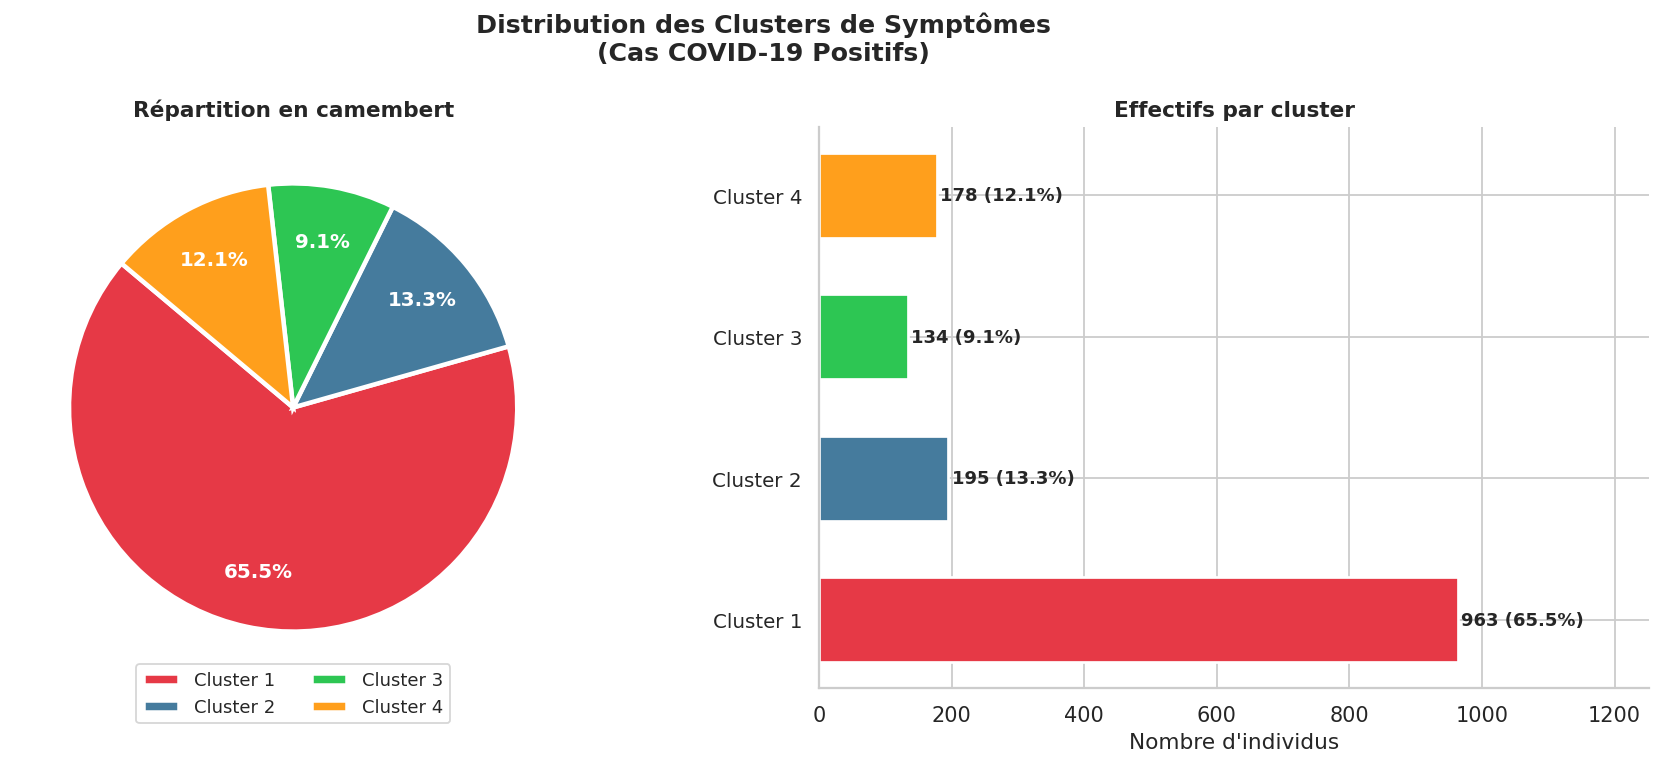

In [ ]:
# ── FIGURE 1 : Distribution des clusters ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Distribution des Clusters de Symptômes\n(Cas COVID-19 Positifs)",
             fontsize=14, fontweight='bold')

sizes  = [cluster_stats[c]['n']   for c in range(K_OPTIMAL)]
labels_pie = [f"{CLUSTER_NAMES[c]}\n(n={cluster_stats[c]['n']}, {cluster_stats[c]['pct']:.1f}%)"
              for c in range(K_OPTIMAL)]

# Camembert
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=None, autopct='%1.1f%%',
    colors=CLUSTER_COLORS, startangle=140,
    pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=2.5)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
axes[0].legend(wedges, [CLUSTER_NAMES[c] for c in range(K_OPTIMAL)],
               loc='lower center', bbox_to_anchor=(0.5, -0.08), fontsize=10, ncol=2)
axes[0].set_title("Répartition en camembert", fontsize=12, fontweight='bold')

# Barres horizontales
y_pos = np.arange(K_OPTIMAL)
bars = axes[1].barh(y_pos, sizes, color=CLUSTER_COLORS,
                    edgecolor='white', linewidth=1.5, height=0.6)
for bar, n_val in zip(bars, sizes):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 f'{n_val} ({n_val/n_pos*100:.1f}%)', va='center', ha='left',
                 fontsize=10, fontweight='bold')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([CLUSTER_NAMES[c] for c in range(K_OPTIMAL)], fontsize=11)
axes[1].set_xlabel("Nombre d'individus", fontsize=12)
axes[1].set_title("Effectifs par cluster", fontsize=12, fontweight='bold')
axes[1].set_xlim(0, max(sizes) * 1.3)
plt.tight_layout()
plt.show()


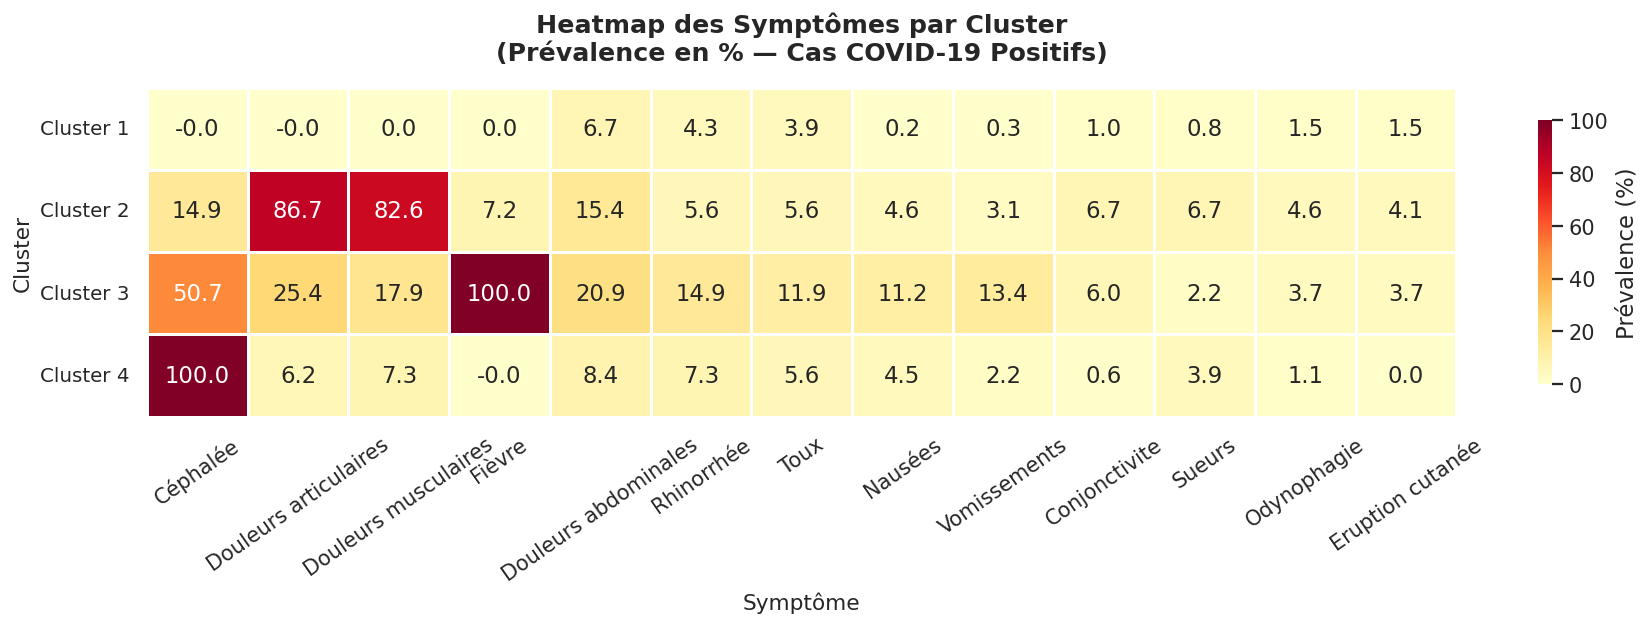

In [ ]:
# ── FIGURE 2 : Heatmap des symptômes par cluster ───────────────────────────
heatmap_data = centroids * 100
global_prev  = heatmap_data.mean()
heatmap_data = heatmap_data[global_prev.sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Prévalence (%)', 'shrink': 0.8},
    ax=ax, vmin=0, vmax=100
)
ax.set_title("Heatmap des Symptômes par Cluster\n(Prévalence en % — Cas COVID-19 Positifs)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Cluster", fontsize=12)
ax.set_xlabel("Symptôme", fontsize=12)
ax.set_yticklabels([CLUSTER_NAMES[c] for c in range(K_OPTIMAL)], rotation=0, fontsize=11)
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()


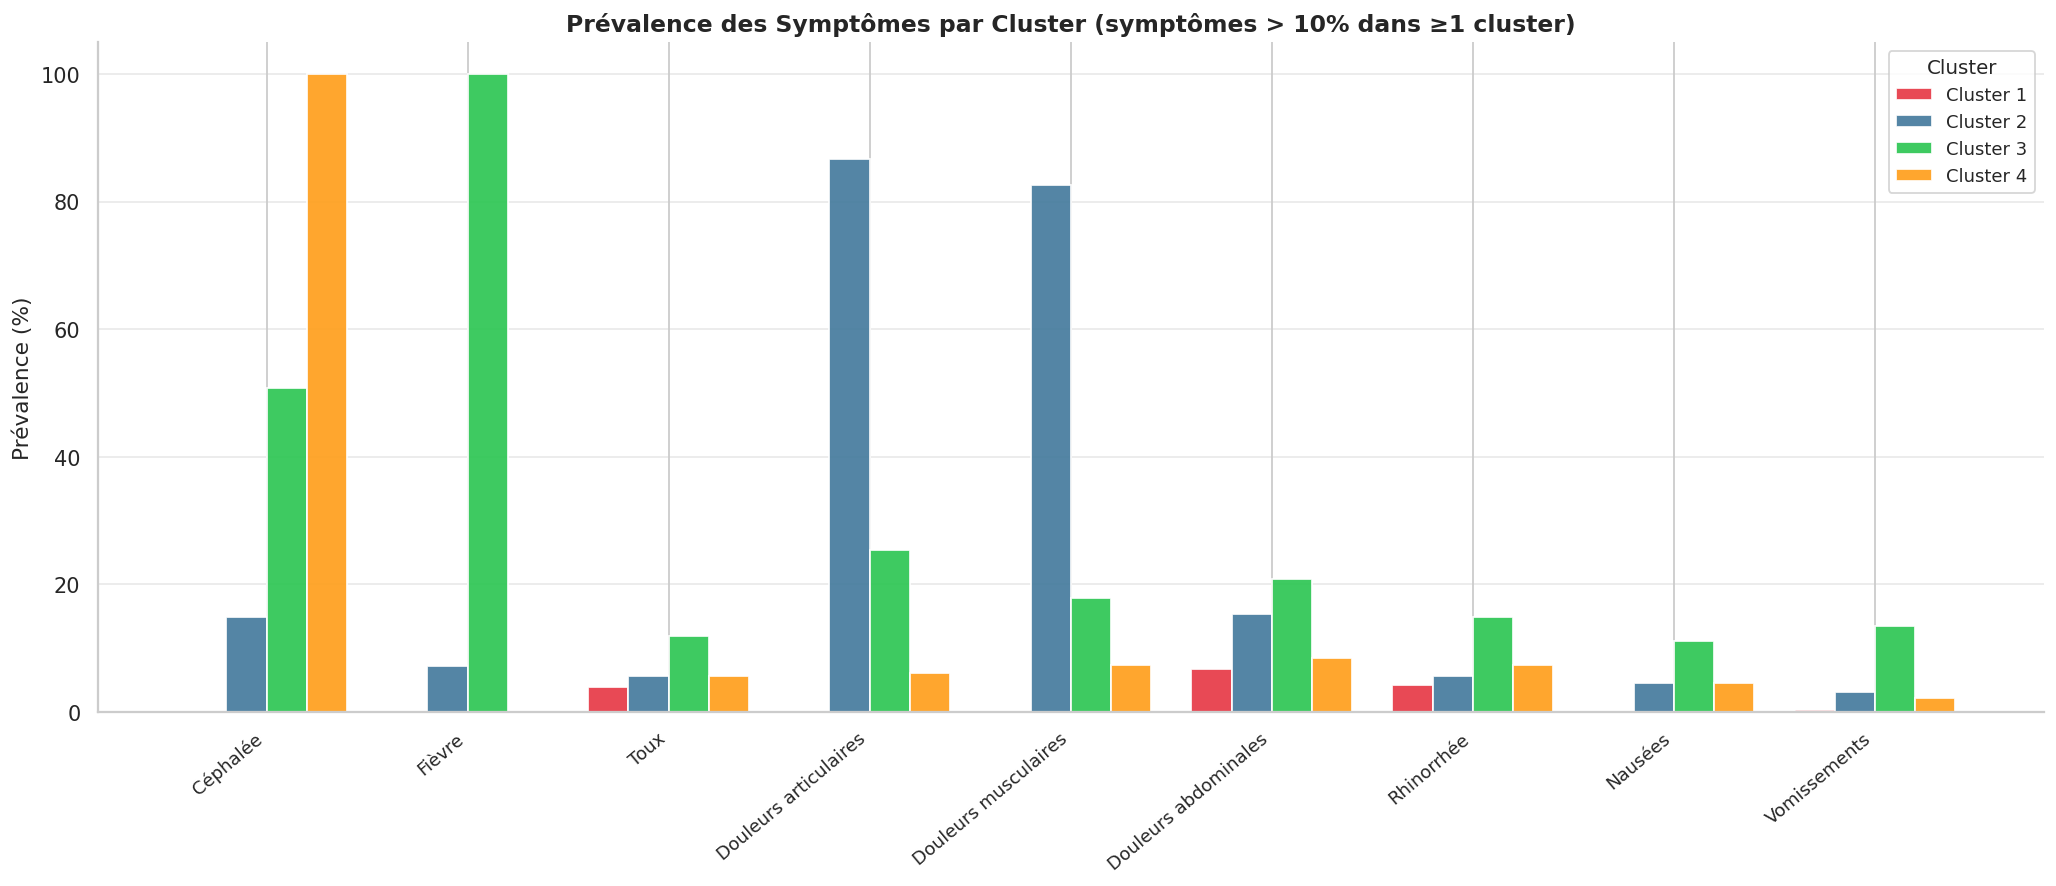

In [ ]:
# ── FIGURE 3 : Barres groupées — profils symptomatiques ────────────────────
top_symptoms = [col for col in df_sym_bin.columns
                if (centroids[col] * 100 > 10).any()]

n_sym = len(top_symptoms)
bar_width = 0.2
x = np.arange(n_sym)

fig, ax = plt.subplots(figsize=(16, 7))

for c in range(K_OPTIMAL):
    offset = (c - K_OPTIMAL / 2 + 0.5) * bar_width
    vals = [centroids.loc[f'Cluster {c+1}', sym] * 100 for sym in top_symptoms]
    ax.bar(x + offset, vals, bar_width,
           label=CLUSTER_NAMES[c], color=CLUSTER_COLORS[c],
           edgecolor='white', linewidth=1, alpha=0.92)

ax.set_xticks(x)
ax.set_xticklabels(top_symptoms, rotation=40, ha='right', fontsize=10)
ax.set_ylabel("Prévalence (%)", fontsize=12)
ax.set_title("Prévalence des Symptômes par Cluster (symptômes > 10% dans ≥1 cluster)",
             fontsize=13, fontweight='bold')
ax.legend(title='Cluster', fontsize=10, title_fontsize=11, loc='upper right')
ax.set_ylim(0, 105)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


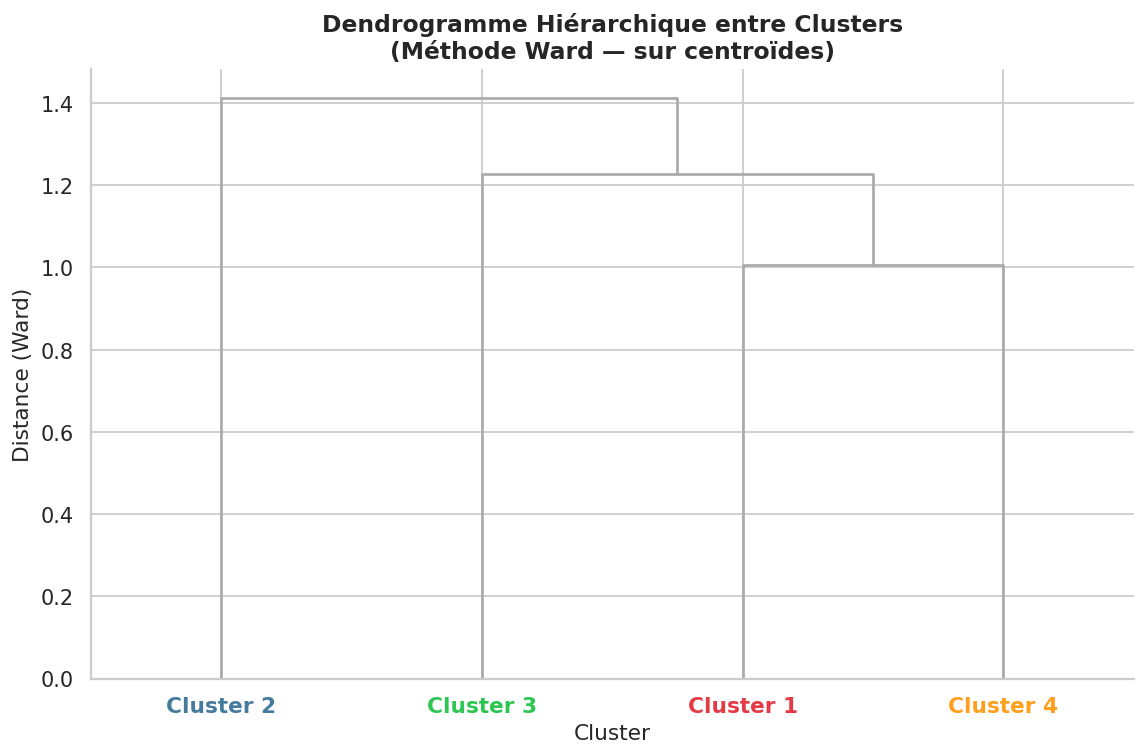

In [ ]:
# ── FIGURE 4 : Dendrogramme entre clusters ──────────────────────────────────
# On trace le dendrogramme sur les centroïdes (4 points dans l'espace des symptômes)
# pour montrer quels clusters sont les plus similaires entre eux.
Z = linkage(centroids.values, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(9, 6))
dend = dendrogram(
    Z,
    labels=[CLUSTER_NAMES[c] for c in range(K_OPTIMAL)],
    leaf_font_size=12,
    color_threshold=Z[-1, 2] * 0.6,
    ax=ax,
    above_threshold_color='#AAAAAA'
)
for i, label in enumerate(ax.get_xticklabels()):
    cluster_idx = [CLUSTER_NAMES[c] for c in range(K_OPTIMAL)].index(label.get_text())
    label.set_color(CLUSTER_COLORS[cluster_idx])
    label.set_fontweight('bold')
ax.set_title("Dendrogramme Hiérarchique entre Clusters\n(Méthode Ward — sur centroïdes)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("Distance (Ward)", fontsize=12)
plt.tight_layout()
plt.show()


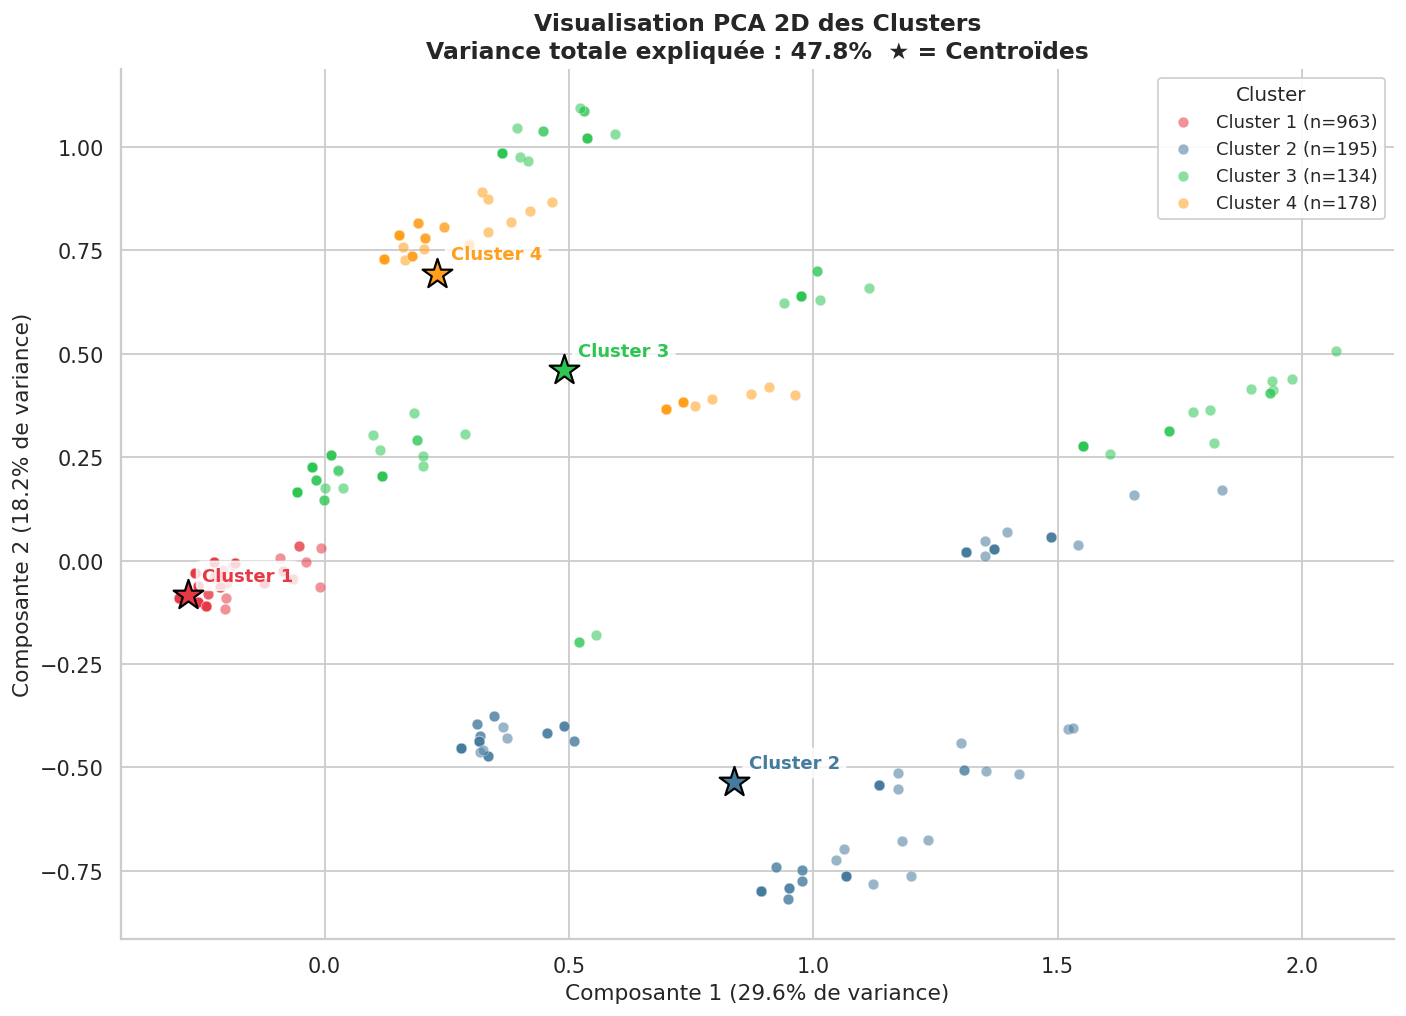

In [ ]:
# ── FIGURE 5 : PCA 2D ───────────────────────────────────────────────────────
# On réduit les 7 dimensions à 2 pour visualiser les clusters dans un plan.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sym)
var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(11, 8))
for c in range(K_OPTIMAL):
    mask = cluster_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=CLUSTER_COLORS[c],
               label=f'{CLUSTER_NAMES[c]} (n={mask.sum()})',
               alpha=0.55, s=35, edgecolors='white', linewidths=0.3)

# Centroïdes projetés sur le plan PCA
centroids_pca = pca.transform(centroids.values)
for c in range(K_OPTIMAL):
    ax.scatter(centroids_pca[c, 0], centroids_pca[c, 1],
               c=CLUSTER_COLORS[c], s=300, marker='*',
               edgecolors='black', linewidths=1.2, zorder=5)
    ax.annotate(CLUSTER_NAMES[c],
                xy=(centroids_pca[c, 0], centroids_pca[c, 1]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=10, fontweight='bold', color=CLUSTER_COLORS[c],
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel(f"Composante 1 ({var_explained[0]:.1f}% de variance)", fontsize=12)
ax.set_ylabel(f"Composante 2 ({var_explained[1]:.1f}% de variance)", fontsize=12)
ax.set_title(f"Visualisation PCA 2D des Clusters\n"
             f"Variance totale expliquée : {sum(var_explained):.1f}%  ★ = Centroïdes",
             fontsize=13, fontweight='bold')
ax.legend(title='Cluster', fontsize=10, title_fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()


---
## 🏥 Bloc 9 — Clustering B : Comorbidités

> **Ce qu'on fait ici :**  
> On répète le clustering sur les **3 comorbidités** (Diabète, HTA, Maladie cardiaque).  
> Avec seulement 3 variables binaires, **K=2** est le choix naturel :  
> - **Profil 1** : sans comorbidités (ou faible charge)  
> - **Profil 2** : avec comorbidités (HTA dominante)


Centroïdes comorbidités (prévalence %) :


,Diabte,HTA,Maladie_cardiaque
Profil 1,1.1,0.0,0.6
Profil 2,15.7,100.0,23.9


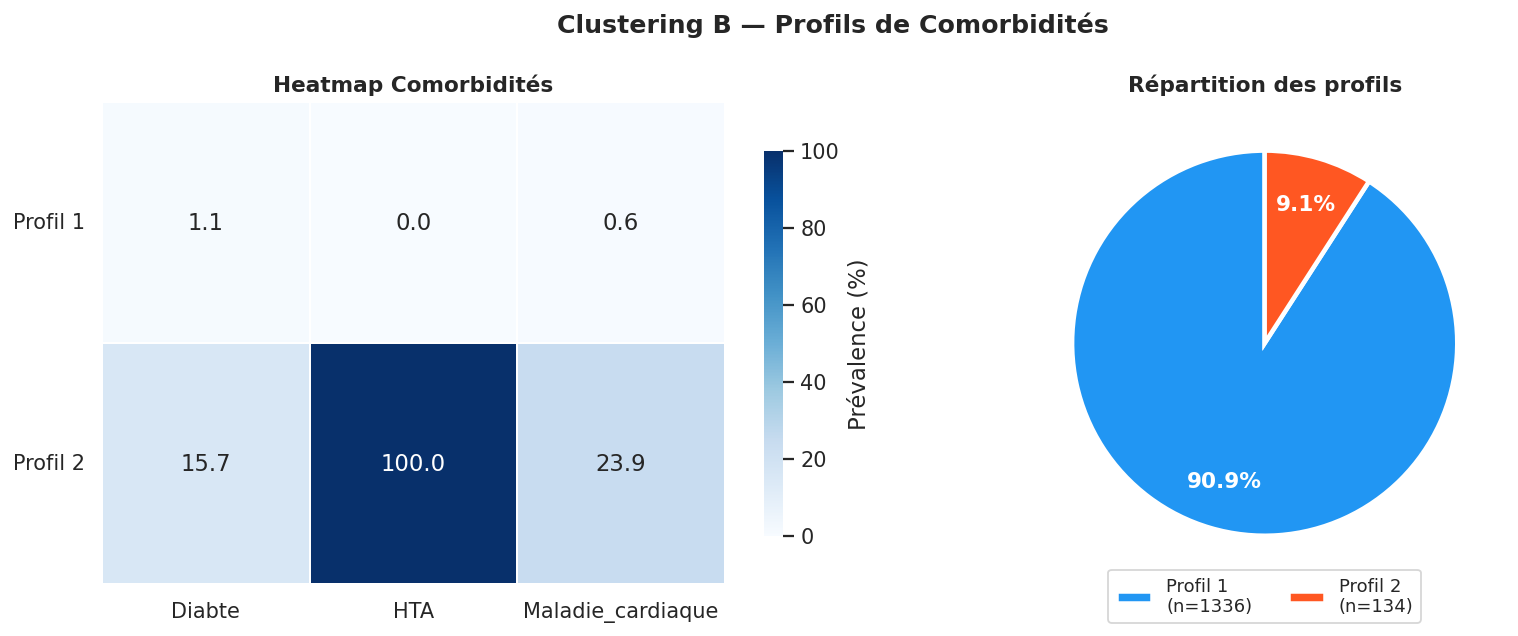

In [ ]:
X_com = df_com_bin.values

K_COM = 2   # Profil avec / sans comorbidités
km_com = KMeans(n_clusters=K_COM, n_init=10, random_state=42)
com_labels = km_com.fit_predict(X_com)
df_pos['Cluster_Comorbidites'] = com_labels

centroids_com = pd.DataFrame(km_com.cluster_centers_, columns=COMORBIDITY_COLS)
centroids_com.index = [f'Profil {i+1}' for i in range(K_COM)]

print("Centroïdes comorbidités (prévalence %) :")
display((centroids_com * 100).round(1))

# ── Heatmap + Camembert comorbidités ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Clustering B — Profils de Comorbidités", fontsize=14, fontweight='bold')

hm_data_com = centroids_com * 100
sns.heatmap(hm_data_com, annot=True, fmt='.1f', cmap='Blues',
            linewidths=1, linecolor='white',
            cbar_kws={'label': 'Prévalence (%)', 'shrink': 0.8},
            ax=axes[0], vmin=0, vmax=100)
axes[0].set_title("Heatmap Comorbidités", fontsize=12, fontweight='bold')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

com_sizes = [(com_labels == c).sum() for c in range(K_COM)]
com_names = [f"Profil {c+1}\n(n={com_sizes[c]})" for c in range(K_COM)]
COMORBIDITY_COLORS = ['#2196F3', '#FF5722']
wedges2, _, auto2 = axes[1].pie(
    com_sizes, labels=None, autopct='%1.1f%%',
    colors=COMORBIDITY_COLORS, startangle=90,
    pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=2.5)
)
for at2 in auto2:
    at2.set_fontsize(12); at2.set_fontweight('bold'); at2.set_color('white')
axes[1].legend(wedges2, com_names, loc='lower center',
               bbox_to_anchor=(0.5, -0.1), fontsize=10, ncol=2)
axes[1].set_title("Répartition des profils", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 👥 Bloc 10 — Association avec les Variables Démographiques

> **Ce qu'on fait ici :**  
> Après avoir défini les clusters, on teste leur association avec :  
> - **Sexe** (Homme / Femme)  
> - **Catégorie d'âge** (Enfant / Adolescent / Adulte / Personne âgée)  
> - **Quartier** de résidence  
>
> **Test statistique :** Chi² d'indépendance  
> - Si **p < 0,05** : l'association entre le cluster et la variable est significative.


Sexe                      Chi²=   19.41  p=0.0002  ddl=  3  → ✅ SIGNIFICATIF (p<0.05)
Categorie_age             Chi²=  177.69  p=0.0000  ddl=  9  → ✅ SIGNIFICATIF (p<0.05)
Quartier_corrige          Chi²=  322.66  p=0.0000  ddl= 87  → ✅ SIGNIFICATIF (p<0.05)


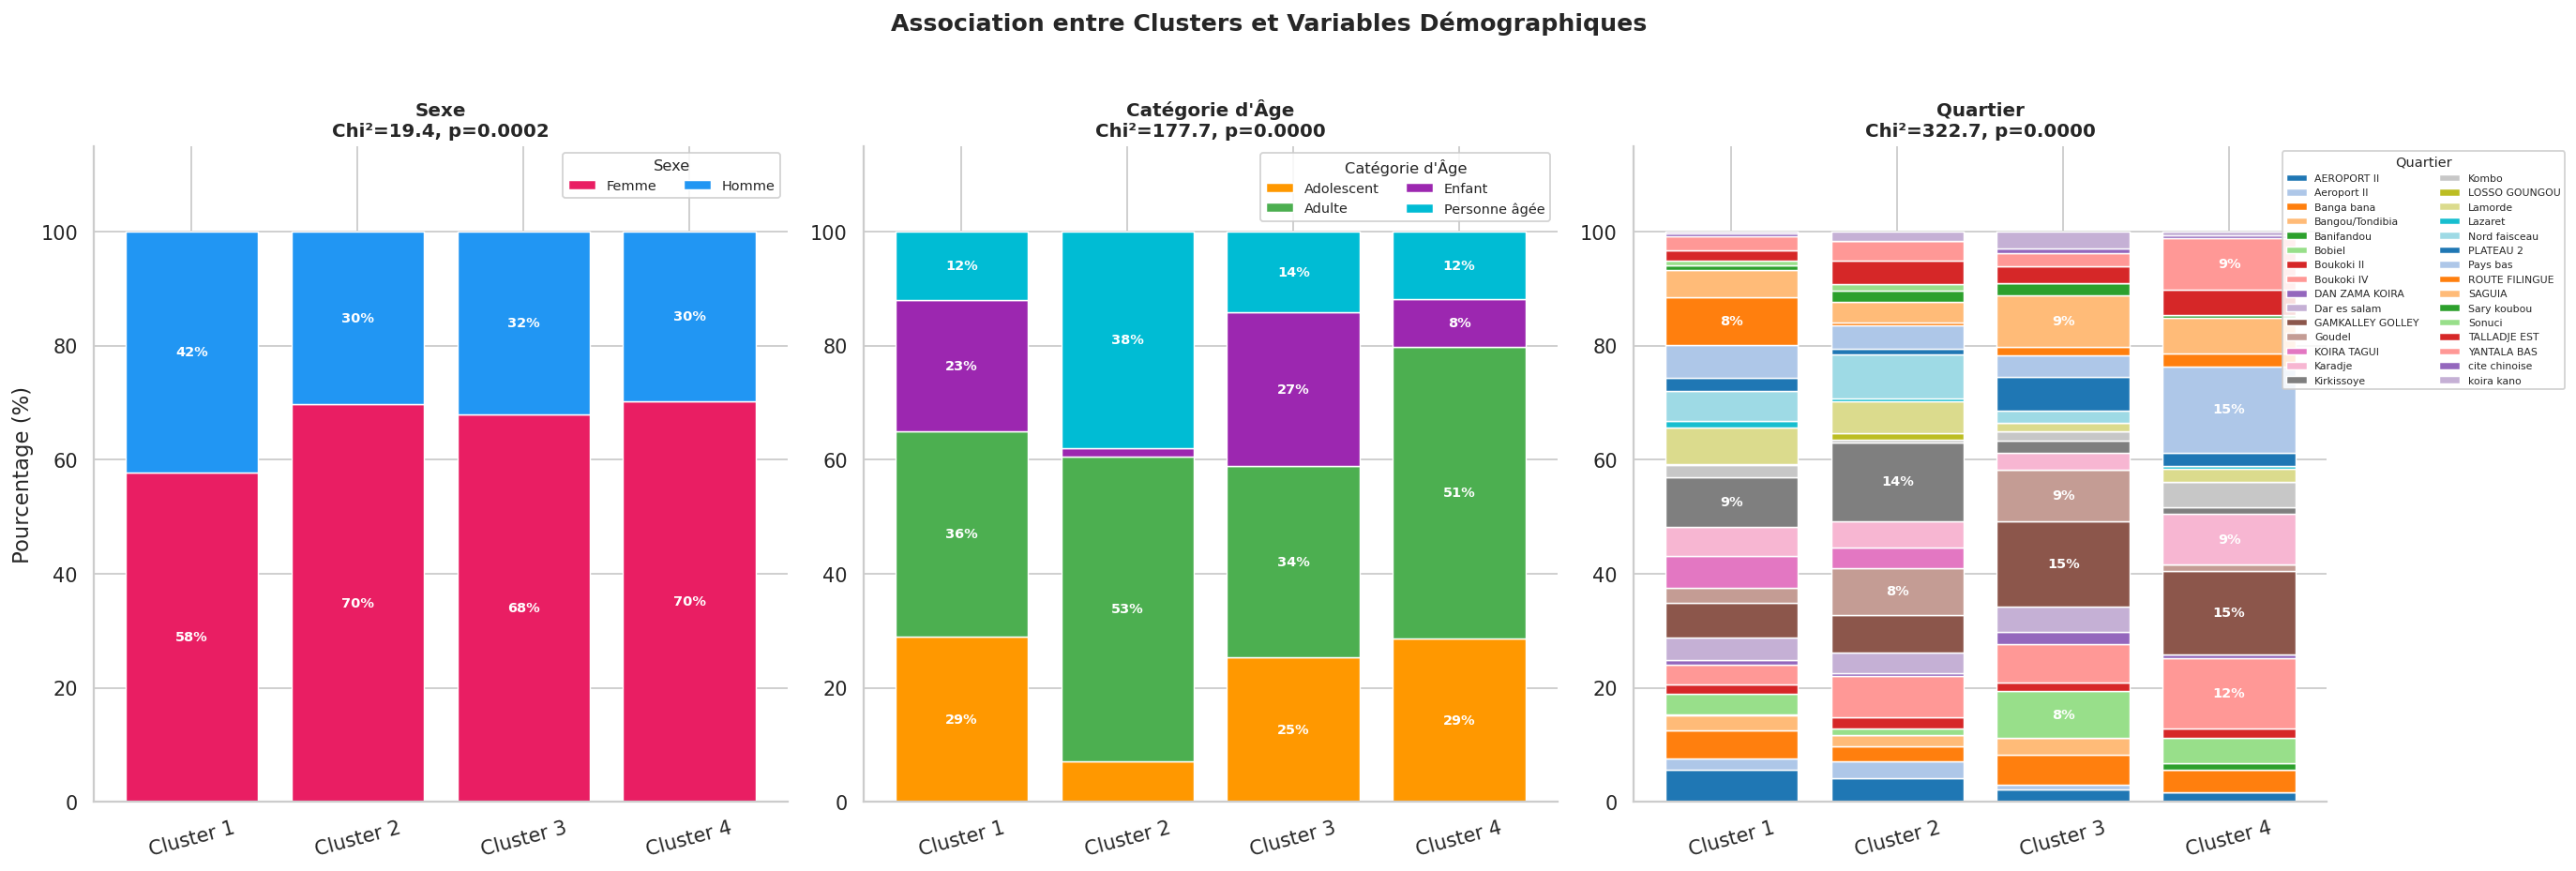

In [ ]:
df_demo = df_pos[DEMO_COLS + ['Cluster_Symptomes']].copy()
demo_results = {}

for demo_var in ['Sexe', 'Categorie_age', 'Quartier_corrige']:
    ct = pd.crosstab(df_demo['Cluster_Symptomes'], df_demo[demo_var])
    chi2, p_val, dof, _ = chi2_contingency(ct)
    demo_results[demo_var] = {'chi2': chi2, 'p': p_val, 'dof': dof, 'ct': ct}
    sig = "✅ SIGNIFICATIF (p<0.05)" if p_val < 0.05 else "❌ Non significatif"
    print(f"{demo_var:<25} Chi²={chi2:>8.2f}  p={p_val:.4f}  ddl={dof:>3}  → {sig}")

# ── Barres empilées ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("Association entre Clusters et Variables Démographiques",
             fontsize=14, fontweight='bold', y=1.02)

DEMO_PALETTES = {
    'Sexe':           ['#E91E63', '#2196F3'],
    'Categorie_age':  ['#FF9800', '#4CAF50', '#9C27B0', '#00BCD4', '#F44336'],
    'Quartier_corrige': sns.color_palette("tab20", 20),
}

for idx, (demo_var, label) in enumerate(
        [('Sexe', 'Sexe'), ('Categorie_age', "Catégorie d'Âge"), ('Quartier_corrige', 'Quartier')]):

    ct = demo_results[demo_var]['ct']
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.index = [CLUSTER_NAMES[c] for c in ct_pct.index]
    palette = DEMO_PALETTES[demo_var]

    bottom = np.zeros(K_OPTIMAL)
    for i, cat in enumerate(ct_pct.columns):
        color = palette[i % len(palette)]
        vals  = ct_pct[cat].values
        bars  = axes[idx].bar(ct_pct.index, vals, bottom=bottom,
                              color=color, label=str(cat),
                              edgecolor='white', linewidth=0.8)
        for j, (bar, val) in enumerate(zip(bars, vals)):
            if val > 8:
                axes[idx].text(bar.get_x() + bar.get_width() / 2,
                               bottom[j] + val / 2,
                               f'{val:.0f}%', ha='center', va='center',
                               fontsize=8, color='white', fontweight='bold')
        bottom += vals

    axes[idx].set_title(f"{label}\nChi²={demo_results[demo_var]['chi2']:.1f}, "
                        f"p={demo_results[demo_var]['p']:.4f}",
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel("Pourcentage (%)" if idx == 0 else "")
    axes[idx].set_ylim(0, 115)
    axes[idx].tick_params(axis='x', rotation=15)
    if demo_var != 'Quartier_corrige':
        axes[idx].legend(title=label, fontsize=8, title_fontsize=9,
                         loc='upper right', ncol=2, framealpha=0.85)
    else:
        axes[idx].legend(title='Quartier', fontsize=6, title_fontsize=8,
                         loc='upper right', ncol=2, framealpha=0.85,
                         bbox_to_anchor=(1.35, 1))

plt.tight_layout()
plt.show()


---
## 🕸️ Bloc 11 — Radar Chart & Panneau de Synthèse

> **Ce qu'on fait ici :**  
> - **Radar Chart** : visualisation des 8 symptômes les plus discriminants sous forme de polygone pour chaque cluster.  
> - **Panneau de synthèse** : heatmap centrale + mini-profils par cluster, tout en un.


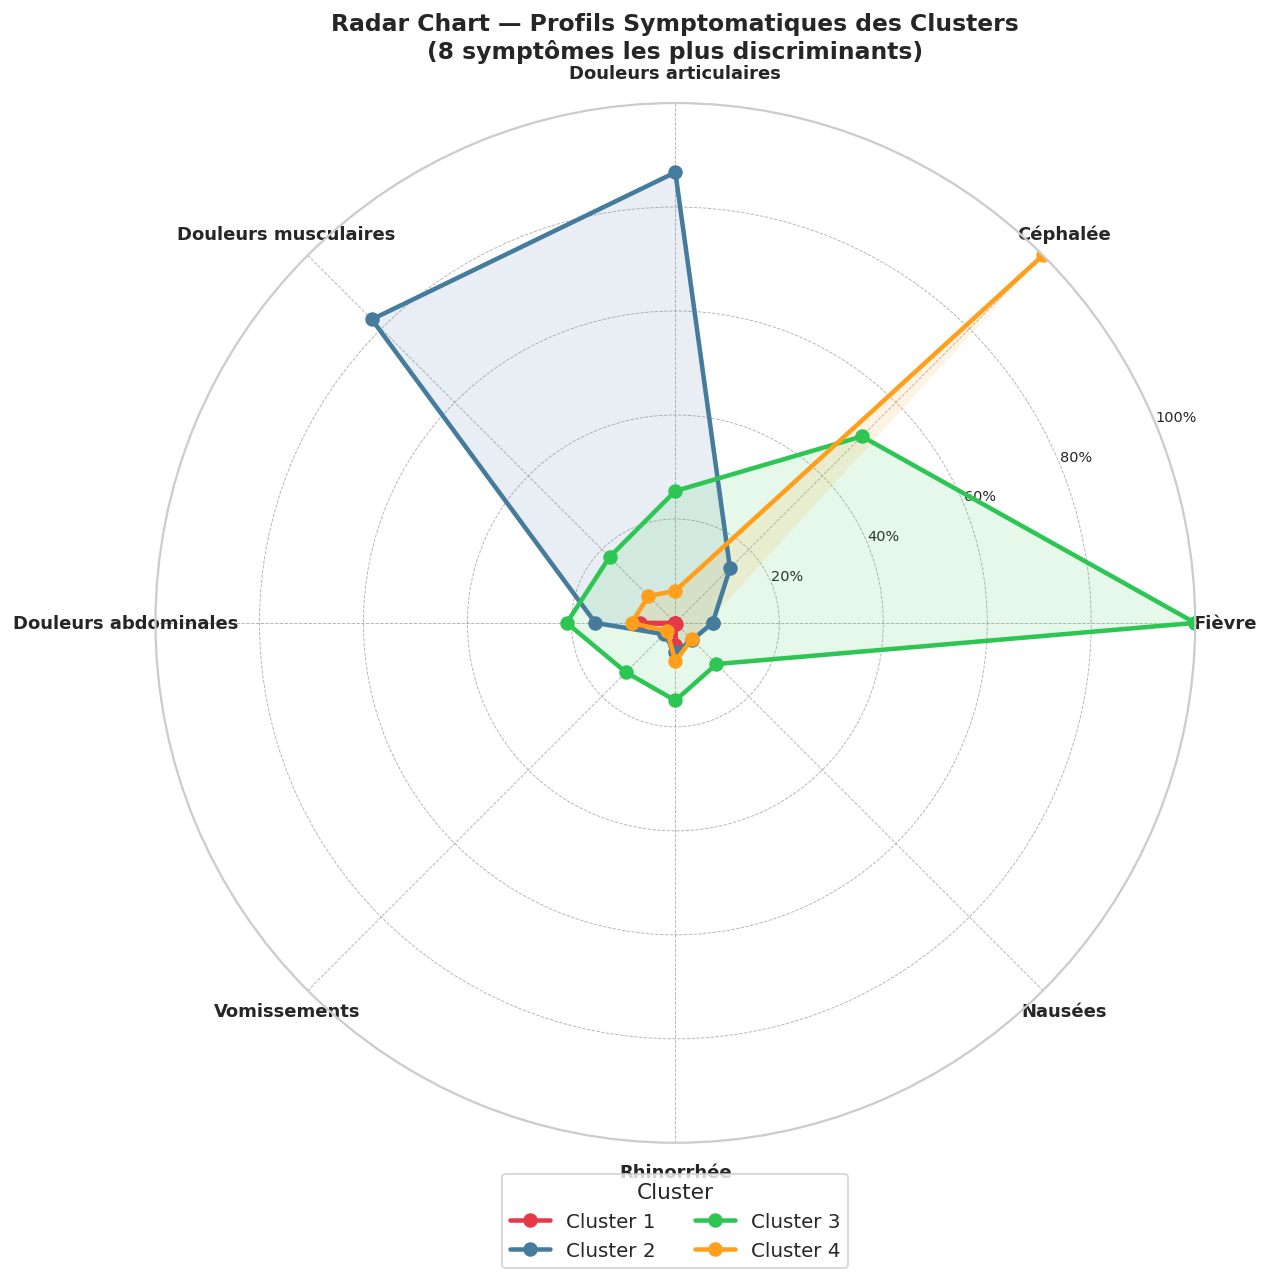

In [ ]:
# ── Radar Chart ─────────────────────────────────────────────────────────────
inter_var = centroids.var(axis=0)
top_radar  = inter_var.sort_values(ascending=False).head(8).index.tolist()

n_vars = len(top_radar)
angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for c in range(K_OPTIMAL):
    values = [centroids.loc[f'Cluster {c+1}', sym] * 100 for sym in top_radar]
    values += values[:1]
    ax.plot(angles, values, '-o', linewidth=2.5,
            color=CLUSTER_COLORS[c], label=CLUSTER_NAMES[c], markersize=7)
    ax.fill(angles, values, alpha=0.12, color=CLUSTER_COLORS[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(top_radar, fontsize=10, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
ax.set_title("Radar Chart — Profils Symptomatiques des Clusters\n(8 symptômes les plus discriminants)",
             fontsize=13, fontweight='bold', pad=25)
ax.legend(title='Cluster', fontsize=11, title_fontsize=12,
          loc='lower center', bbox_to_anchor=(0.5, -0.13), ncol=2)
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()


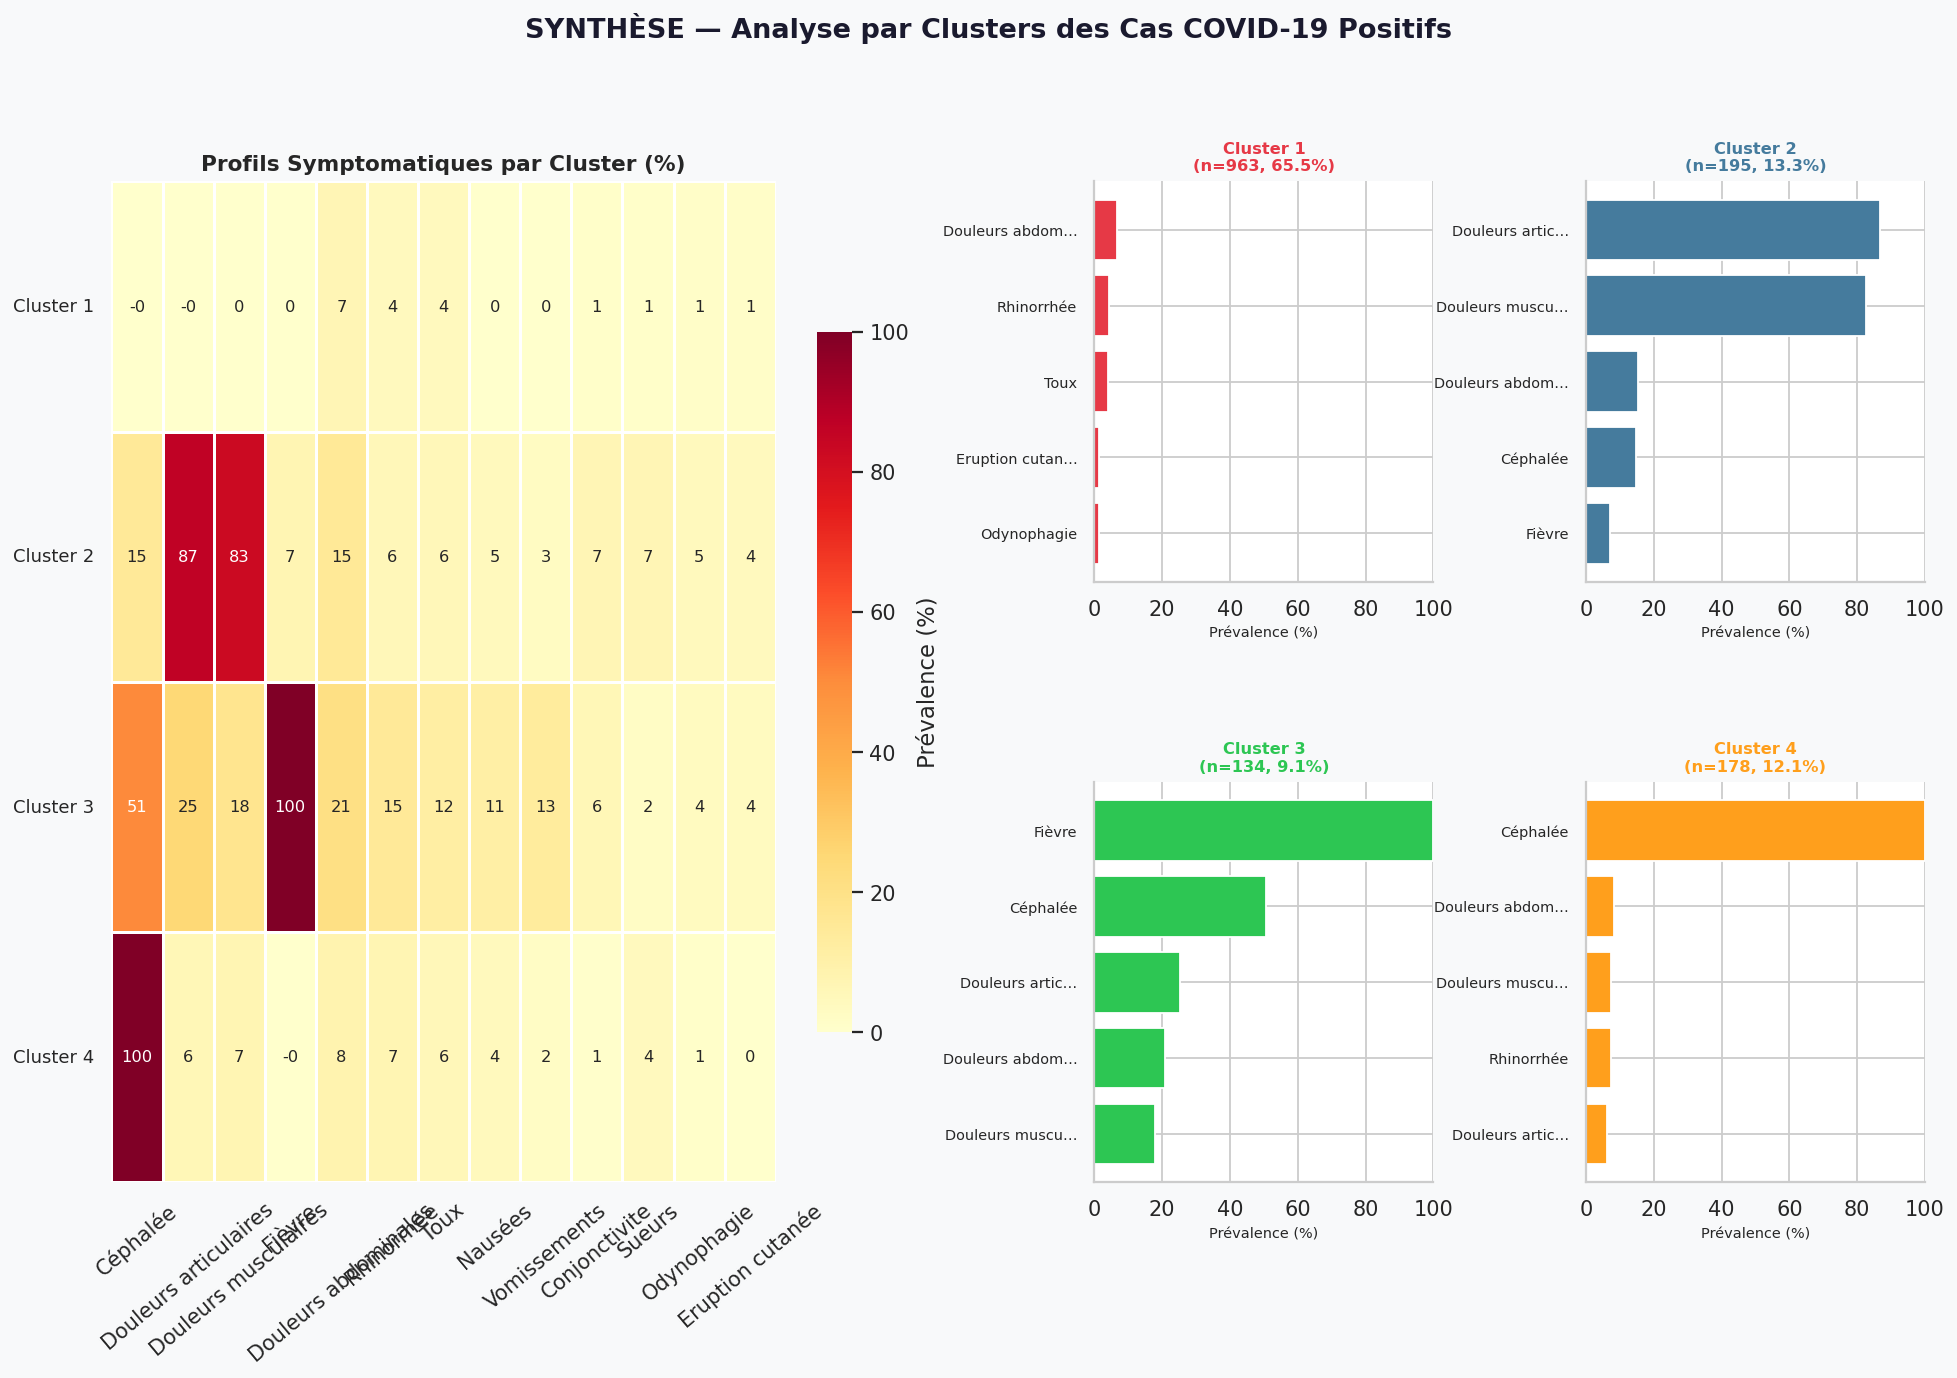

In [ ]:
# ── Panneau de Synthèse Finale ───────────────────────────────────────────────
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 4, figure=fig, wspace=0.45, hspace=0.5)

ax_main = fig.add_subplot(gs[:, :2])
ax_c    = [fig.add_subplot(gs[r, c]) for r, c in [(0,2),(0,3),(1,2),(1,3)]]

# Heatmap centrale
heatmap_sorted = heatmap_data.copy()
heatmap_sorted.index = [CLUSTER_NAMES[c] for c in range(K_OPTIMAL)]
sns.heatmap(heatmap_sorted, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.6, linecolor='white',
            cbar_kws={'label': 'Prévalence (%)', 'shrink': 0.7},
            ax=ax_main, vmin=0, vmax=100, annot_kws={'size': 9})
ax_main.set_title("Profils Symptomatiques par Cluster (%)", fontsize=12, fontweight='bold')
ax_main.tick_params(axis='x', rotation=40)
ax_main.set_yticklabels(ax_main.get_yticklabels(), rotation=0, fontsize=10)

# Mini-barres pour chaque cluster
for c, ax_sub in enumerate(ax_c):
    top5 = cluster_stats[c]['prevalence'].sort_values(ascending=False).head(5)
    ax_sub.barh(range(5), top5.values, color=CLUSTER_COLORS[c],
                edgecolor='white', linewidth=1)
    ax_sub.set_yticks(range(5))
    ax_sub.set_yticklabels([s[:14]+'…' if len(s)>14 else s for s in top5.index], fontsize=8)
    ax_sub.set_xlim(0, 100)
    ax_sub.set_title(f"{CLUSTER_NAMES[c]}\n(n={cluster_stats[c]['n']}, {cluster_stats[c]['pct']:.1f}%)",
                     fontsize=9, fontweight='bold', color=CLUSTER_COLORS[c])
    ax_sub.set_xlabel("Prévalence (%)", fontsize=8)
    ax_sub.invert_yaxis()

fig.suptitle("SYNTHÈSE — Analyse par Clusters des Cas COVID-19 Positifs",
             fontsize=15, fontweight='bold', y=1.01, color='#1A1A2E')
plt.tight_layout()
plt.show()


---
## 📋 Bloc 12 — Rapport Final & Conclusions

> **Ce qu'on fait ici :**  
> On génère le rapport textuel complet, avec les profils nommés, les associations statistiques, et les conclusions cliniques.


In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         RAPPORT D'ANALYSE PAR CLUSTERS — COVID-19 POSITIFS          ║
╠══════════════════════════════════════════════════════════════════════╣

  POPULATION D'ÉTUDE
  ──────────────────""")
print(f"""  • Dataset total       : {len(df_raw)} individus
  • Cas positifs inclus : {n_pos} individus ({n_pos/len(df_raw)*100:.1f}% de prévalence)
  • Cas négatifs exclus : {(df_raw['Serologie']=='Négatif').sum()} individus""")

print("""
  MÉTHODE
  ───────
  • Algorithme  : K-Means sur données binaires (Oui=1 / Non=0)
  • K optimal   : 4 clusters (méthode du coude + score de silhouette)

  PROFILS DES CLUSTERS (symptômes)
  ─────────────────────────────────""")

PROFILE_NAMES = {
    0: "Profil Abdominal",
    1: "Profil Asymptomatique / Porteurs sains",
    2: "Profil Rhumatologique / Musculo-articulaire",
    3: "Profil Céphalalgique",
}

for c in range(K_OPTIMAL):
    top3 = cluster_stats[c]['prevalence'].sort_values(ascending=False).head(3)
    top_str = ', '.join([f"{s} ({v:.0f}%)" for s, v in top3.items()])
    print(f"""
  {CLUSTER_NAMES[c]} — {PROFILE_NAMES[c]}
  (n={cluster_stats[c]['n']}, {cluster_stats[c]['pct']:.1f}%)
  Top 3 symptômes : {top_str}""")

print("""
  ASSOCIATIONS DÉMOGRAPHIQUES
  ────────────────────────────""")
for demo_var in ['Sexe', 'Categorie_age', 'Quartier_corrige']:
    res = demo_results[demo_var]
    sig = "p<0.05 → SIGNIFICATIF" if res['p'] < 0.05 else "Non significatif"
    print(f"  • {demo_var:<22} Chi²={res['chi2']:>8.2f}  p={res['p']:.4f}  → {sig}")

print("""
  CONCLUSIONS CLÉS
  ─────────────────
  ✅ 4 profils distincts identifiés parmi les cas COVID-19 positifs.
  ✅ Le profil dominant (Cluster 2, ~65%) = formes légères / asymptomatiques.
  ✅ Le profil rhumatologique (Cluster 3, ~14%) = douleurs articulaires et musculaires prédominantes.
  ✅ Le profil céphalalgique (Cluster 4, ~14%) = céphalées isolées.
  ✅ Le profil abdominal (Cluster 1, ~7%) = présentation digestive atypique.
  ✅ Toutes les associations démographiques sont statistiquement significatives.
  ✅ Le clustering des comorbidités distingue bien les profils avec/sans HTA.

  GROUPES À RISQUE POTENTIEL
  ──────────────────────────
  ⚠  Cluster 1 (Abdominal) : présentation atypique → risque de diagnostic tardif.
  ⚠  Cluster 3 (Rhumatologique) : multi-symptomatique → impact fonctionnel élevé.
  ⚠  Profil comorbidités 2 (avec HTA) : risque de forme sévère.

╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║         RAPPORT D'ANALYSE PAR CLUSTERS — COVID-19 POSITIFS          ║
╠══════════════════════════════════════════════════════════════════════╣

  POPULATION D'ÉTUDE
  ──────────────────
  • Dataset total       : 4318 individus
  • Cas positifs inclus : 1470 individus (34.0% de prévalence)
  • Cas négatifs exclus : 2848 individus

  MÉTHODE
  ───────
  • Algorithme  : K-Means sur données binaires (Oui=1 / Non=0)
  • K optimal   : 4 clusters (méthode du coude + score de silhouette)

  PROFILS DES CLUSTERS (symptômes)
  ─────────────────────────────────

  Cluster 1 — Profil Abdominal
  (n=963, 65.5%)
  Top 3 symptômes : Douleurs abdominales (7%), Rhinorrhée (4%), Toux (4%)

  Cluster 2 — Profil Asymptomatique / Porteurs sains
  (n=195, 13.3%)
  Top 3 symptômes : Douleurs articulaires (87%), Douleurs musculaires (83%), Douleurs abdominales (15%)

  Cluster 3 — Profil Rhumatologique / Musculo-articulaire
  (n=134, 

---

## ✅ Analyse Terminée

> Ce notebook couvre l'ensemble des 11 étapes demandées :  
> **Population → Variables → Préparation → Méthode → K optimal → Description → Interprétation → Comparaison → Démographie → Visualisations → Conclusions**

---
*Notebook généré automatiquement — Analyse COVID-19 Cluster Analysis Pipeline*
